# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [45]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [6]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:

usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [19]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:

# cantidad de nulos para users
print("Valores nulos en users:")
print(users.isna().sum())

Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [13]:
print("Valores nulos en usage:")
print(usage.isna().sum())

Valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  

Diagnóstico de valores nulos (dataset users)

Valores nulos

city (~469 registros): presenta una proporción moderada de valores faltantes.
👉 Acción recomendada: Investigar e imputar si es relevante para el análisis (por ejemplo, usar “Unknown” o la ciudad más frecuente); si no es una variable clave, puede mantenerse como nula.

churn_date (~3534 registros): alto número de nulos, pero esperado, ya que corresponde a usuarios que no han cancelado el servicio.
👉 Acción recomendada: No eliminar ni imputar; interpretar los nulos como usuarios activos y utilizar esta columna como indicador de churn.

Resto de columnas: no presentan valores nulos.
👉 Acción recomendada: No requieren tratamiento.

✅ Conclusión:
No se identifican problemas críticos de calidad de datos; los valores nulos en churn_date son informativos y los de city solo requieren una decisión según su relevancia en el análisis.

Diagnóstico de valores nulos (dataset usage)

Valores nulos

date (≈50 registros, proporción muy baja): pocos valores faltantes.
👉 Acción recomendada: Eliminar esas filas o imputar si no afectan series de tiempo; el impacto es mínimo.

duration (≈22.076 registros, proporción alta): muchos nulos, probablemente asociados a eventos donde la duración no aplica (ej. SMS).
👉 Acción recomendada: No imputar globalmente; mantener nulos y tratarlos según el tipo (type) del evento.

length (≈17.896 registros, proporción alta): alto número de nulos, posiblemente para eventos donde no existe longitud (ej. llamadas).
👉 Acción recomendada: Mantener nulos y analizar esta variable solo para los tipos donde es relevante.

Resto de columnas (id, user_id, type): sin valores faltantes.
👉 Acción recomendada: No requieren acción.

✅ Conclusión:
Los valores nulos en usage son estructurales y esperados según el tipo de uso, por lo que no deben imputarse de forma automática; se deben manejar de manera condicionada en el análisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB



- La columna `user_id` funciona como identificador; los valores son consecutivos y no tiene significado analítico, por lo que no se usa para análisis estadístico.
- La columna `age` no presenta valores nulos y, según el resumen estadístico, se mantiene dentro de rangos razonables; no se identifican sentinels evidentes.


In [15]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB



- Las columnas `id` y `user_id`son identificadores, no presentan valores nulos y no tienen significado analítico directo; se usan para identificar registros y relacionar datasets.
- Las columnas `duration` y `length` contienen una alta proporción de valores nulos, lo cual es esperado porque solo aplican a ciertos tipos de uso; no deben imputarse de forma global y deben analizarse según la variable type.


In [16]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   city    3531 non-null   object
 1   plan    4000 non-null   object
dtypes: object(2)
memory usage: 62.6+ KB


- La columna `city` es categórica y presenta valores nulos; además puede contener muchas categorías distintas, por lo que podría requerir imputación (por ejemplo “Unknown”) o limpieza/estandarización si se usa en el análisis.
- La columna `plan`es categórica, no tiene valores nulos y sus categorías deben corresponder a los planes definidos en el dataset plans; no se observan inconsistencias aparentes.

In [17]:

# explorar columna categórica de usage
usage['type'].unique()


array(['call', 'text'], dtype=object)

- La columna `type` es categórica y solo presenta los valores 'call' y 'text', lo cual es consistente y esperado; no se observan sentinels ni categorías inesperadas, por lo que no requiere tratamiento adicional.


---

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- 
**Columnas numéricas** (age, duration, length): no se identifican valores fuera de rangos lógicos; los valores nulos en duration y length son estructurales y dependen del tipo de uso.
Acción: no eliminar ni imputar de forma global; analizar estas columnas de manera condicionada.

**Columnas categóricas** (city, plan, type): no se observan categorías inesperadas; city presenta nulos pero no valores inválidos.
Acción: estandarizar o imputar city solo si es relevante para el análisis.
Conclusión:
No se detectan sentinels críticos; el dataset es consistente y solo requiere validaciones según contexto de uso.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [19]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [20]:
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


En `reg_date` se observa que la columna fue convertida correctamente al tipo fecha (datetime), lo que permite extraer y analizar componentes como el año sin inconvenientes; no se identifican valores fuera del rango esperado.

In [22]:
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB



En `date`, se observa que la columna fue convertida correctamente al tipo fecha (datetime), permitiendo analizar los registros de uso en el tiempo; estas fechas se consideran válidas y serán la base para el análisis temporal.



✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Años imposibles: No se identifican años muy antiguos ni fechas futuras posteriores a 2024 en las columnas de fecha analizadas.
Acción recomendada: No se requiere corrección; se mantienen todas las fechas para el análisis.

Fechas inválidas (NaT tras la conversión): Corresponden a errores de formato o registros incompletos.
Acción recomendada: Excluir estos registros del análisis temporal para evitar sesgos.

Conclusión:
Las fechas son consistentes y confiables; el dataset está listo para análisis basado en tiempo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:

# Reemplazar -999 por la mediana de age


users['age'] = users['age'].replace(-999, pd.NA)
mediana_age = users['age'].median()
users['age'] = users['age'].fillna(mediana_age)


# Verificar cambios
users['age'].isna().sum()

0

In [24]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()





565

In [25]:


# Marcar fechas futuras como NA para reg_date (posteriores a 2024)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()





40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [31]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())



type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [32]:

# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())



type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Análisis (MAR – duration por type)**

call: 0.000 → No hay valores nulos en duration; la duración es totalmente aplicable a llamadas.
text: 0.999 → Casi todos los registros son nulos; la duración no aplica a mensajes.
Conclusión:
Los nulos en duration dependen del tipo de uso, por lo que son MAR y estructurales.
Acción recomendada:
Mantener los nulos (no imputar) y analizar duration solo para call.

**Análisis (MAR – length por type)**

call: 0.999 → Casi todos los valores son nulos; la longitud no aplica a llamadas.
text: 0.000 → No hay valores nulos; la longitud es totalmente aplicable a mensajes.
Conclusión:
Los nulos en length dependen del tipo de uso, confirmando que son MAR y estructurales.
Acción recomendada:
Mantener los nulos (no imputar) y analizar length solo para text.



---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [33]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# Observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [35]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [47]:

# Resumen estadístico de las columnas numéricas relevantes
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()



,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [49]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100)





Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

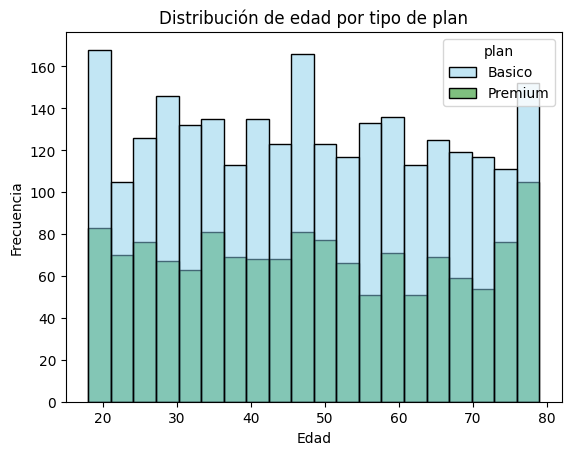

In [68]:
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- La distribución de edad es bastante uniforme y similar entre los planes Básico y Premium, sin concentraciones extremas en rangos específicos.
- No se observan diferencias marcadas que indiquen que un plan esté claramente asociado a un grupo etario particular.

- La forma de la distribución es aproximadamente simétrica, sin sesgos fuertes hacia edades jóvenes o mayores.

Conclusión:
La edad no parece ser un factor diferenciador clave entre los usuarios de plan Básico y Premium; ambos planes presentan perfiles etarios comparables.


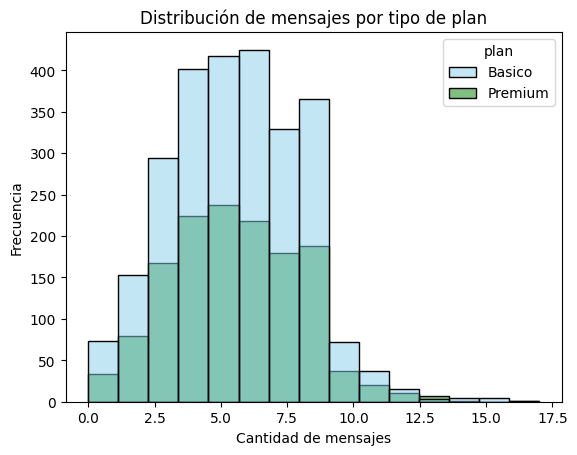

In [67]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)
plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución de cantidad de mensajes está sesgada a la derecha, ya que la mayoría de los usuarios envía pocos mensajes y solo algunos presentan valores altos.

- Los usuarios del plan Premium muestran una ligera mayor concentración en rangos medios y altos de mensajes frente al plan Básico.

- En ambos planes, el mayor volumen de usuarios se concentra aproximadamente entre 3 y 7 mensajes.

Conclusión:
Aunque ambos planes presentan patrones similares, el plan Premium tiende a un uso ligeramente más intensivo de mensajes, mientras que el plan Básico se concentra más en volúmenes bajos a medios.

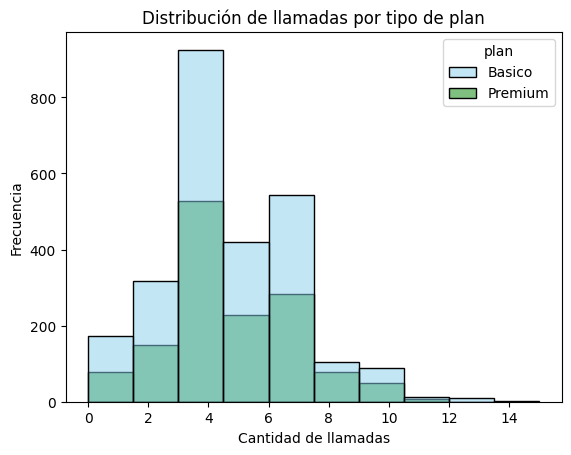

In [58]:

# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)
plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()



💡Insights: 
- La distribución de la cantidad de llamadas está sesgada a la derecha, con la mayoría de los usuarios concentrados en valores bajos a medios.

- Los usuarios del plan Premium presentan una mayor dispersión y aparecen con más frecuencia en rangos altos de llamadas en comparación con el plan Básico.

- El plan Básico concentra la mayor parte de usuarios entre 3 y 6 llamadas, mientras que Premium se extiende hacia valores más altos.

Conclusión:
Aunque ambos planes muestran patrones similares, el plan Premium tiende a un uso más intensivo de llamadas, especialmente en los valores extremos.


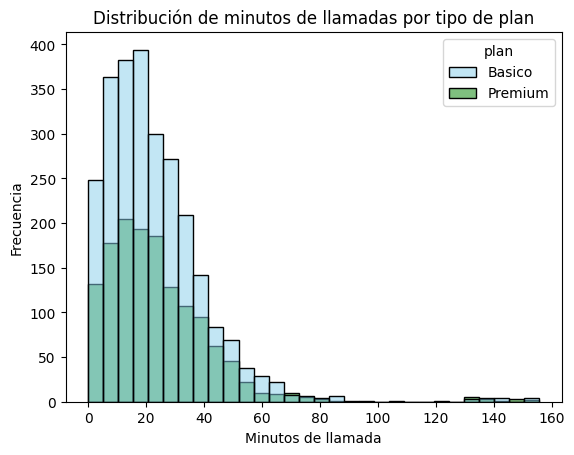

In [63]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=30
)
plt.title('Distribución de minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 

- La distribución de los minutos de llamadas también está sesgada a la derecha, lo que indica que la mayoría de los usuarios consume pocos minutos y unos pocos concentran consumos muy altos.

- Los usuarios del plan Básico se concentran principalmente entre 5 y 30 minutos, con una caída progresiva a medida que aumentan los minutos.

- El plan Premium muestra una cola más larga, alcanzando valores mucho más altos (incluso >120 minutos), lo que evidencia mayor intensidad de uso.

Conclusión:
Los usuarios Premium tienden a realizar llamadas más largas, no solo más frecuentes. Esto sugiere un perfil de cliente con mayor dependencia del servicio de llamadas, lo que justifica un plan de mayor valor.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

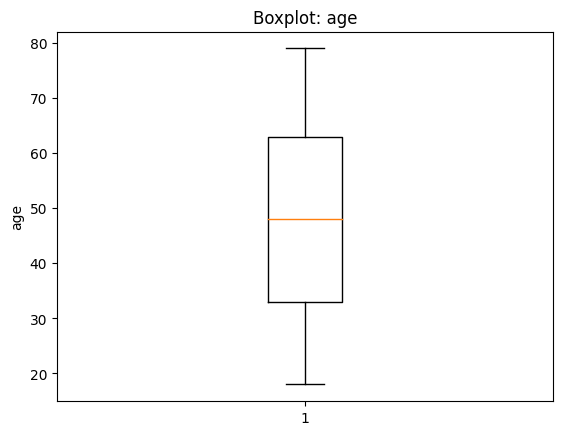

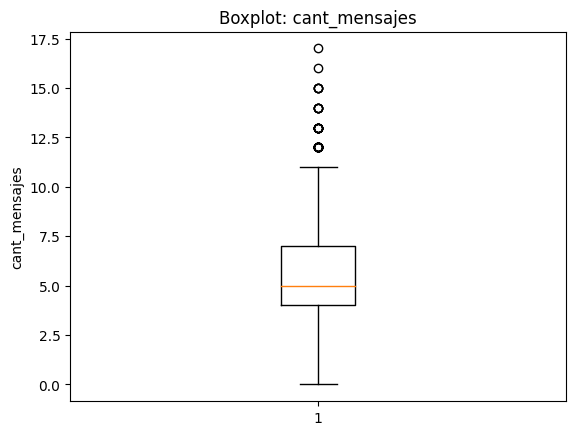

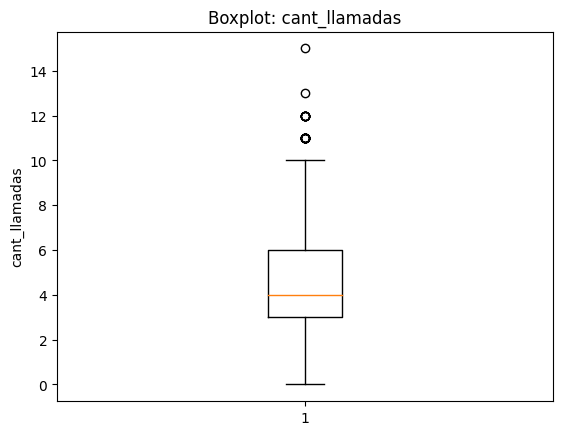

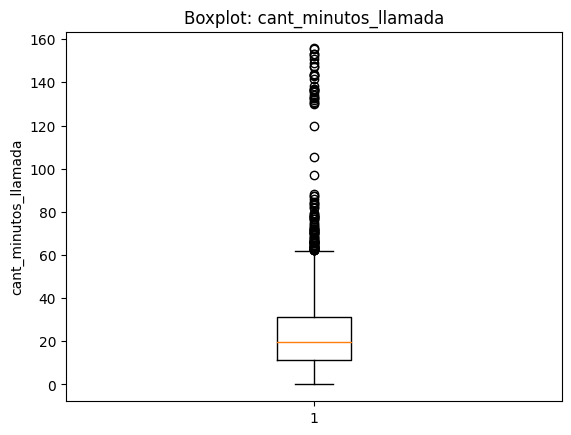

In [73]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()


💡Insights: 
- Age:
Mediana cercana a 48 años.
La mayoría de usuarios está entre 33 y 63 años.
No se detectan outliers ni valores irreales.

- cant_mensajes:
La mayoría de usuarios envía ~5 mensajes (mediana).
Uso estable: la mitad de los datos está entre 4 y 7 mensajes.
Hay outliers altos (12–17) → usuarios muy activos.
Existe asimetría positiva (más valores extremos hacia arriba).
Algunos usuarios tienen 0 mensajes (posible inactividad).

- cant_llamadas:
Mediana cercana a 4 llamadas.
La mayoría de usuarios se concentra entre 3 y 6 llamadas.
Se observan outliers altos (≈10–15 llamadas), asociados a usuarios con uso intensivo del servicio.

- cant_minutos_llamada:
Mediana cercana a 20 minutos.
La mayoría de usuarios se concentra entre 10 y 30 minutos de llamada.
Se detectan múltiples outliers altos (60–155 minutos), lo que indica un grupo reducido de usuarios con tiempos de llamada muy elevados.

In [82]:


# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"Columna: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {lower}")
    print(f"Límite superior: {upper}")
  




Columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5
Columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5
Columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [79]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes:
Se mantienen los outliers porque representan usuarios con uso intensivo real del servicio y no valores erróneos. No distorsionan fuertemente la distribución.

- cant_llamadas:
Se mantienen los outliers ya que corresponden a clientes con alta frecuencia de llamadas, un comportamiento válido dentro del negocio.

- cant_minutos_llamada:
Se mantienen los outliers, aunque son más extremos, porque reflejan usuarios con tiempos de llamada muy altos. Sin embargo, podrían requerir transformación (ej. log) en modelos para reducir sesgo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [83]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) &
    (user_profile['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'
] = 'Uso medio'

In [84]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [86]:
# Crear columna grupo_edad
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

user_profile.loc[
    (user_profile['age'] < 60) & (user_profile['grupo_edad'] != 'Joven'),
    'grupo_edad'
] = 'Adulto'



In [87]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

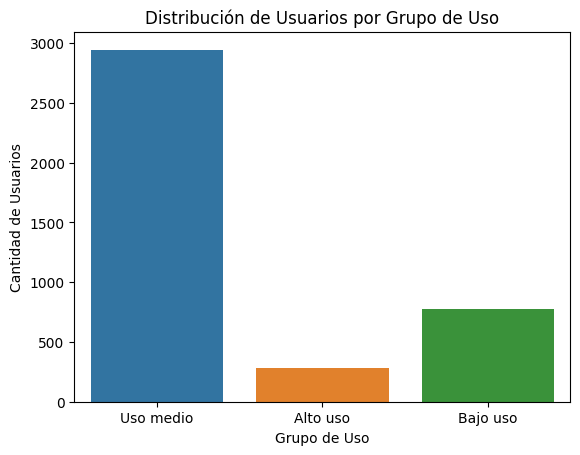

In [88]:


# Visualización de los segmentos por uso

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()




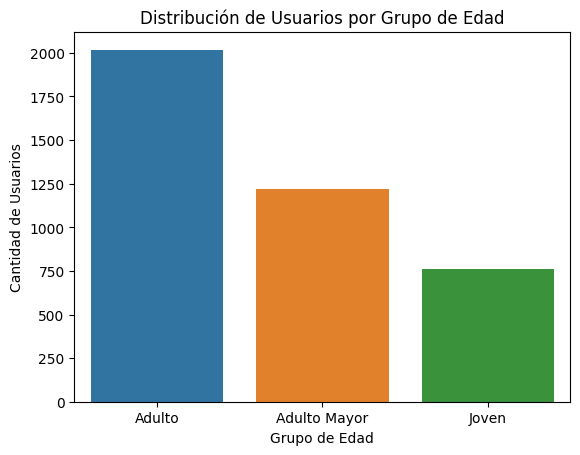

In [89]:
# Visualización de los segmentos por edad
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()




---

## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
- Valores sentinels en edad (age = -999): representaban una pequeña proporción del dataset y fueron reemplazados por la mediana para evitar distorsiones en el análisis demográfico.
- Valores inválidos en city ("?"): indicaban errores de captura; se reemplazaron por valores nulos para no asumir información incorrecta.
Fechas fuera de rango: se detectaron registros con fechas posteriores a 2024, las cuales se marcaron como nulas al considerarse errores de registro.
- Valores nulos en duration y length: se comprobó que dependen del tipo de evento (call o text), confirmando que son MAR (Missing At Random), por lo que se mantuvieron como nulos sin imputación.

🔍 **Segmentos por Edad**

- Jóvenes (< 30 años): presentan un uso moderado del servicio, con mayor énfasis en mensajes que en llamadas.
- Adultos (30–59 años): conforman el segmento más numeroso y muestran un uso equilibrado entre llamadas y mensajes.
- Adultos Mayores (60+): representan una proporción menor, con menor volumen total de uso, especialmente en mensajes.


📊 **Segmentos por Nivel de Uso**
- Bajo uso: usuarios con baja frecuencia de llamadas y mensajes; probablemente utilizan el servicio de forma ocasional.
- Uso medio: el grupo más grande; presentan un comportamiento estable y predecible.
- Alto uso: aunque minoritario, concentra los mayores volúmenes de llamadas y minutos, generando un impacto relevante en el consumo del servicio.

➡️ Esto sugiere que el negocio está sostenido principalmente por usuarios de uso medio, mientras que el crecimiento de ingresos puede venir del segmento de alto uso.


💡 **Recomendaciones**
- Crear o reforzar planes premium o ilimitados dirigidos a usuarios de alto uso, especialmente aquellos con altos minutos de llamada.
- Diseñar planes livianos o de bajo costo para usuarios de bajo uso, evitando que paguen por servicios que no consumen.
- Implementar estrategias de upselling para usuarios de uso medio, incentivándolos a migrar a planes superiores.
- Explorar campañas diferenciadas por edad: planes digitales y flexibles para jóvenes, y planes simples y enfocados en llamadas para adultos mayores.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`